In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
from pathlib import Path

train_csv_path = Path("/content/drive/MyDrive/data/splits/train.csv") # Path to the train manifest
cnn_data_root = Path("/content/drive/MyDrive/data/processed/cnn") # Root directory for CNN npy files

df = pd.read_csv(train_csv_path)
print(f"Original row count in CSV: {len(df)}")

def file_exists(row, data_root):
    stem = Path(row['filename']).stem
    full_path = data_root / row['composer'] / f"{stem}.npy"
    return full_path.exists()

# Filter out rows where the file does not exist on disk
# Apply the function row-wise using apply with axis=1
df['exists'] = df.apply(lambda row: file_exists(row, cnn_data_root), axis=1)
df_clean = df[df['exists']].drop(columns=['exists'])

print(f"Cleaned row count: {len(df_clean)}")
print(f"Removed {len(df) - len(df_clean)} missing file references.")

# Save back to CSV
df_clean.to_csv(train_csv_path, index=False)

Original row count in CSV: 2187
Cleaned row count: 2187
Removed 0 missing file references.


In [4]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

# Set this to your OUT_DIR path
OUT_DIR = Path("/content/drive/MyDrive/data/processed")  # update if your path differs

corrupt_paths = []

print("Scanning for corrupt or empty .npy files...")
for npy_file in OUT_DIR.rglob("*.npy"):
    try:
        # Check if 0 bytes or unreadable by numpy
        if npy_file.stat().st_size == 0:
            raise EOFError("0-byte file")

        # Test loading the file array
        _ = np.load(npy_file)

    except Exception as e:
        print(f"Removing corrupt file ({e}): {npy_file.name}")
        corrupt_paths.append(str(npy_file))
        os.remove(npy_file)

print(f"Done! Cleaned up {len(corrupt_paths)} corrupted files.")

train_csv_path = OUT_DIR.parent / "train.csv"
if train_csv_path.exists():
    df_train = pd.read_csv(train_csv_path)

    # Keep only rows where the file actually exists on disk
    initial_count = len(df_train)
    df_train['full_path'] = df_train['npy_path'].apply(lambda p: str(OUT_DIR.parent.parent / p))
    df_train = df_train[df_train['full_path'].apply(lambda p: Path(p).exists())]
    df_train = df_train.drop(columns=['full_path'])

    df_train.to_csv(train_csv_path, index=False)
    print(f"Updated train.csv: dropped {initial_count - len(df_train)} missing rows. New total: {len(df_train)}")

Scanning for corrupt or empty .npy files...
Done! Cleaned up 0 corrupted files.


In [5]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

class PianoRollDataset(Dataset):
    def __init__(self, manifest_path, data_dir, window_size=120):
        self.df = pd.read_csv(manifest_path)
        self.data_dir = Path(data_dir)
        self.window_size = window_size

        # Automatically map composer names to integer labels (0 to 3)
        self.composers = sorted(self.df['composer'].unique())
        self.label_map = {name: idx for idx, name in enumerate(self.composers)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        stem = Path(row['filename']).stem
        npy_path = self.data_dir / row['composer'] / f"{stem}.npy"

        roll = np.load(npy_path)

        time_steps = roll.shape[1]
        if time_steps >= self.window_size:
            start_idx = np.random.randint(0, time_steps - self.window_size + 1)
            window = roll[:, start_idx : start_idx + self.window_size]
        else:
            pad_amount = self.window_size - time_steps
            window = np.pad(roll, ((0, 0), (0, pad_amount)), mode='constant')


        window = window.astype(np.float32) / 127.0

        window = np.expand_dims(window, axis=0)

        label = self.label_map[row['composer']]

        return torch.tensor(window), torch.tensor(label, dtype=torch.long)

In [6]:
SPLITS_DIR = "/content/drive/MyDrive/data/splits"
CNN_DIR = "/content/drive/MyDrive/data/processed/cnn"

# Create the dataset
train_dataset = PianoRollDataset(
    manifest_path=f"{SPLITS_DIR}/train.csv",
    data_dir=CNN_DIR,
    window_size=120
)

# Create the data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Test the output shape
for images, labels in train_loader:
    print(f"Batch Image Shape: {images.shape}") # Should be [32, 1, 88, 120]
    print(f"Batch Label Shape: {labels.shape}") # Should be [32]
    break

Batch Image Shape: torch.Size([32, 1, 88, 120])
Batch Label Shape: torch.Size([32])


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Dimensions: (88, 187)


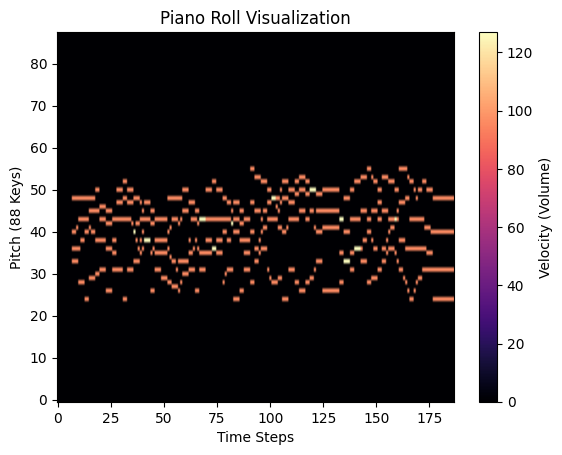

In [7]:
import numpy as np
import matplotlib.pyplot as plt

roll = np.load("/content/drive/MyDrive/data/processed/cnn/bach/003706b_.npy")

print(roll)
print(f"Dimensions: {roll.shape}")

plt.imshow(roll, aspect='auto', origin='lower', cmap='magma')
plt.title("Piano Roll Visualization")
plt.ylabel("Pitch (88 Keys)")
plt.xlabel("Time Steps")
plt.colorbar(label="Velocity (Volume)")
plt.show()

DATASET DISTRIBUTION REPORT

--- TRAIN SET (2187 total chunks) ---
Bach: 717 chunks (32.8%)
Beethoven: 459 chunks (21.0%)
Chopin: 474 chunks (21.7%)
Mozart: 537 chunks (24.6%)

--- VAL SET (245 total chunks) ---
Bach: 153 chunks (62.4%)
Beethoven: 33 chunks (13.5%)
Chopin: 21 chunks (8.6%)
Mozart: 38 chunks (15.5%)

--- TEST SET (246 total chunks) ---
Bach: 154 chunks (62.6%)
Beethoven: 33 chunks (13.4%)
Chopin: 20 chunks (8.1%)
Mozart: 39 chunks (15.9%)


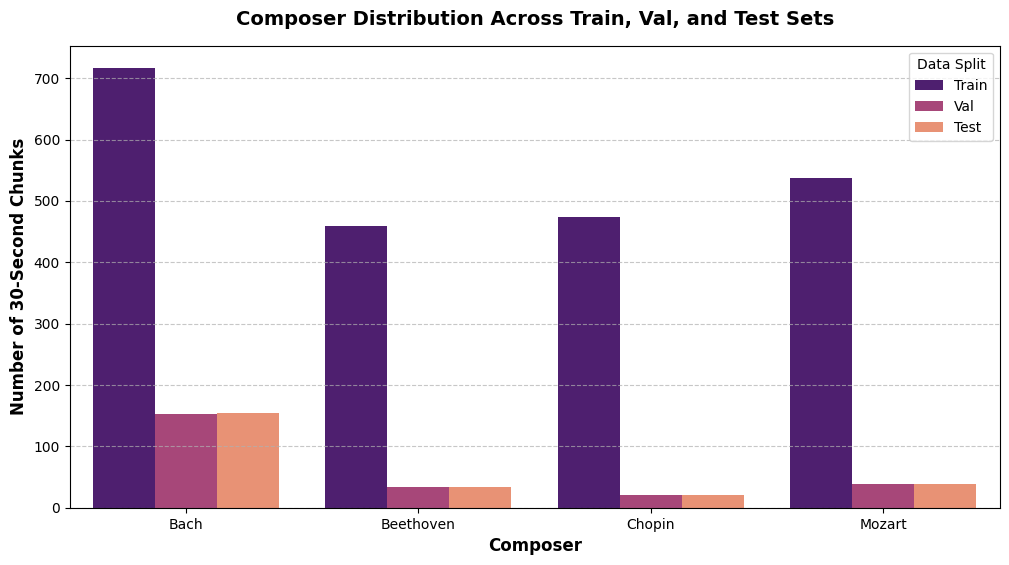

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

splits = ['train', 'val', 'test']
raw_composers = ['bach', 'beethoven', 'chopin', 'mozart'] # Lowercase as they appear in CSV
composer_classes = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
lower_to_cap_map = dict(zip(raw_composers, composer_classes))

plot_data = []

print("=" * 40)
print("DATASET DISTRIBUTION REPORT")
print("=" * 40)

for split in splits:
    csv_path = f"{SPLITS_DIR}/{split}.csv"
    df = pd.read_csv(csv_path)
    total_samples = len(df)

    counts = df['composer'].value_counts().reindex(raw_composers, fill_value=0)

    counts.index = counts.index.map(lower_to_cap_map)

    print(f"\n--- {split.upper()} SET ({total_samples} total chunks) ---")

    for composer, count in counts.items():
        percentage = (count / total_samples) * 100 if total_samples > 0 else 0
        print(f"{composer}: {count} chunks ({percentage:.1f}%)")

        plot_data.append({
            'Dataset': split.capitalize(),
            'Composer': composer,
            'Count': count
        })

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='Composer',
    y='Count',
    hue='Dataset',
    palette='magma'
)

plt.title('Composer Distribution Across Train, Val, and Test Sets', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of 30-Second Chunks', fontsize=12, fontweight='bold')
plt.xlabel('Composer', fontsize=12, fontweight='bold')
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [9]:
import pandas as pd
from torch.utils.data import DataLoader

df_val = pd.read_csv(f"{SPLITS_DIR}/val.csv")

val_dataset = PianoRollDataset(
    manifest_path=f"{SPLITS_DIR}/val.csv",
    data_dir=CNN_DIR,
    window_size=120
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Validation set loaded with {len(val_dataset)} samples.")

Validation set loaded with 245 samples.


## Model ##

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ComposerCNN(nn.Module):
  def __init__(self, num_classes=4, dropout_rate=0.5):
    super(ComposerCNN, self).__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size=(12,1), padding=1)
    self.bn1 = nn.BatchNorm2d(16)
    self.pool1 = nn.MaxPool2d(kernel_size=(2,2))

    self.conv2 = nn.Conv2d(16, 32, kernel_size=(1,16), padding=1)
    self.bn2 = nn.BatchNorm2d(32)
    self.pool2 = nn.MaxPool2d(kernel_size=(2,2))

    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(64)
    self.pool3 = nn.MaxPool2d(kernel_size=(2,2))

    self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(128)
    self.pool4 = nn.MaxPool2d(2, 2)

    self.dropout=nn.Dropout(dropout_rate)

    self.flattened_size = 128 * 5 * 6

    self.fc1 = nn.Linear(self.flattened_size, 256)
    self.bn5 = nn.BatchNorm1d(256)
    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.pool1(F.relu(self.bn1(self.conv1(x))))
    x = self.pool2(F.relu(self.bn2(self.conv2(x))))
    x = self.pool3(F.relu(self.bn3(self.conv3(x))))
    x = self.pool4(F.relu(self.bn4(self.conv4(x))))

    x = x.view(-1, self.flattened_size)

    x = F.relu(self.bn5(self.fc1(x)))
    x = self.dropout(x)
    x = self.fc2(x)
    return x

In [11]:
if __name__ == "__main__":
  model = ComposerCNN()

  dummy_input=torch.randn(32,1,88,120)

  model=ComposerCNN(num_classes=4)
  output=model(dummy_input)

  print(output.shape)

torch.Size([32, 4])


## Calculate Weights and Train/Val ##

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

print("Calculating class weights from the training set...")

df_train = pd.read_csv(f"{SPLITS_DIR}/train.csv")

y_train = df_train['composer'].values
unique_classes = np.unique(y_train)

weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)

composer_classes = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
for composer, weight in zip(composer_classes, weights):
    print(f"{composer} Weight: {weight:.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

Calculating class weights from the training set...
Bach Weight: 0.7626
Beethoven Weight: 1.1912
Chopin Weight: 1.1535
Mozart Weight: 1.0182


In [13]:
import copy
import torch

class EarlyStopping:

    def __init__(self, patience=10, min_delta=0.0):

        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        if val_loss < (self.best_loss - self.min_delta):
            self.best_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            print(f"--> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best_weights(self, model):
        """Reloads the best saved weights back into the model."""
        if self.best_model_weights is not None:
            model.load_state_dict(self.best_model_weights)
            print("Successfully restored best model weights from peak epoch!")

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

model = ComposerCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
early_stopper = EarlyStopping(patience=10, min_delta=0.001)

print("Starting Training & Validation with Early Stopping...")

for epoch in range(epochs):

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = 100. * train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100. * val_correct / val_total

    print(f"Epoch [{epoch+1:02d}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")

    early_stopper(epoch_val_loss, model)
    if early_stopper.early_stop:
        print(f"\n[Early Stopping] Triggered at epoch {epoch+1}. Stopping training!")
        break

early_stopper.restore_best_weights(model)
print("Finished Training!")

Training on device: cuda
Starting Training & Validation with Early Stopping...
Epoch [01/30] | Train Loss: 1.0310 - Train Acc: 56.65% | Val Loss: 0.7952 - Val Acc: 66.12%
Epoch [02/30] | Train Loss: 0.8283 - Train Acc: 66.03% | Val Loss: 0.7188 - Val Acc: 73.47%
Epoch [03/30] | Train Loss: 0.7224 - Train Acc: 71.56% | Val Loss: 1.9539 - Val Acc: 29.39%
--> EarlyStopping counter: 1 out of 10
Epoch [04/30] | Train Loss: 0.6912 - Train Acc: 72.52% | Val Loss: 0.9743 - Val Acc: 53.88%
--> EarlyStopping counter: 2 out of 10
Epoch [05/30] | Train Loss: 0.6327 - Train Acc: 74.81% | Val Loss: 0.6117 - Val Acc: 80.00%
Epoch [06/30] | Train Loss: 0.5944 - Train Acc: 75.72% | Val Loss: 1.6859 - Val Acc: 38.78%
--> EarlyStopping counter: 1 out of 10
Epoch [07/30] | Train Loss: 0.5865 - Train Acc: 76.13% | Val Loss: 0.6375 - Val Acc: 77.55%
--> EarlyStopping counter: 2 out of 10
Epoch [08/30] | Train Loss: 0.5592 - Train Acc: 77.87% | Val Loss: 1.0272 - Val Acc: 68.16%
--> EarlyStopping counter: 3 

In [19]:
print(early_stopper.best_loss)

0.34472942538559437


## Eval against Test data ##

In [20]:
from torch.utils.data import DataLoader

print("Loading test dataset...")

test_dataset = PianoRollDataset(
    manifest_path=f"{SPLITS_DIR}/test.csv",
    data_dir=CNN_DIR,
    window_size=120
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()

test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = 100. * correct / total

print("=" * 40)
print(f"TEST RESULTS | Loss: {avg_test_loss:.4f} | Accuracy: {test_acc:.2f}%")
print("=" * 40)

Loading test dataset...
TEST RESULTS | Loss: 0.4064 | Accuracy: 85.37%


In [25]:
import numpy as np
from sklearn.metrics import classification_report
classification_report = classification_report(all_labels, all_preds, target_names=composer_classes)
print(classification_report)

              precision    recall  f1-score   support

        Bach       0.99      0.86      0.92       154
   Beethoven       0.58      0.91      0.71        33
      Chopin       0.94      0.85      0.89        20
      Mozart       0.71      0.77      0.74        39

    accuracy                           0.85       246
   macro avg       0.81      0.85      0.82       246
weighted avg       0.89      0.85      0.86       246



In [21]:
import torch

# Define the path where you want to save the model
save_path = "/content/drive/MyDrive/data/composer_cnn_weights.pth"

# Save the model's learned weights
torch.save(model.state_dict(), save_path)

print(f"Model successfully saved to {save_path}!")

Model successfully saved to /content/drive/MyDrive/data/composer_cnn_weights.pth!


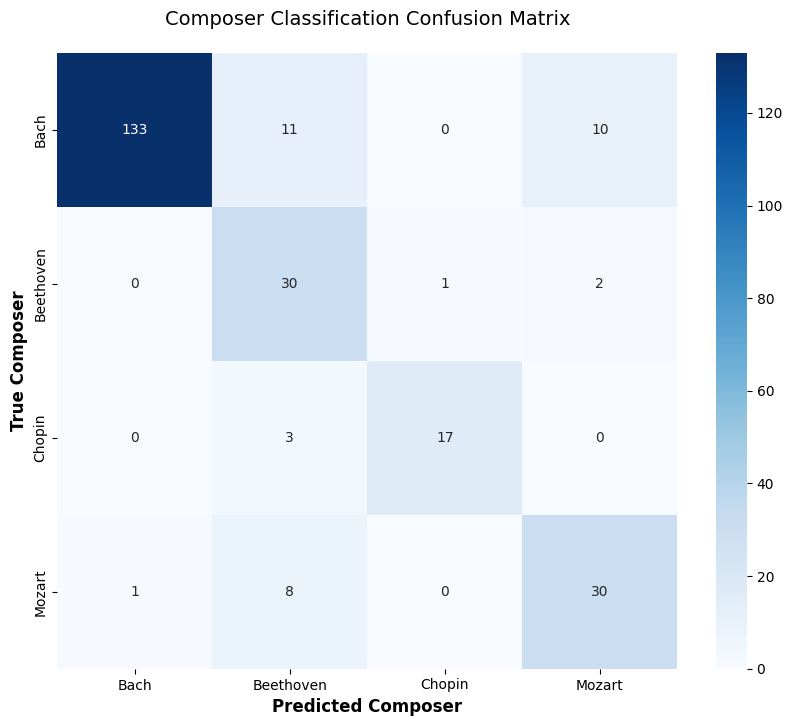

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

composer_classes = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=composer_classes,
    yticklabels=composer_classes
)

plt.xlabel('Predicted Composer', fontsize=12, fontweight='bold')
plt.ylabel('True Composer', fontsize=12, fontweight='bold')
plt.title('Composer Classification Confusion Matrix', fontsize=14, pad=20)

plt.show()

## Hyperparameterize the model for best performance ##

In [23]:
!pip install optuna

In [31]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)

    model = ComposerCNN(num_classes=4).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    epochs = 10

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100. * correct / total


    trial.report(val_acc,epoch)

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return val_acc

In [32]:
# Create a study object
pruner=optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=5)
study = optuna.create_study(direction="maximize")

# Run the optimization for a set number of trials
print("Starting Hyperparameter Optimization...")
study.optimize(objective, n_trials=20)

# Print the best results
print("\nBest trial:")
trial = study.best_trial

print(f"  Validation Accuracy: {trial.value:.2f}%")
print("  Best Hyperparameters: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-08-07 21:02:52,399] A new study created in memory with name: no-name-0b5e058c-e72c-4b22-9d45-0423e58fd61d


Starting Hyperparameter Optimization...


[I 2026-08-07 21:03:46,013] Trial 0 finished with value: 60.40816326530612 and parameters: {'lr': 0.003525351713387418, 'dropout_rate': 0.26076530325897596}. Best is trial 0 with value: 60.40816326530612.
[I 2026-08-07 21:04:36,489] Trial 1 finished with value: 82.85714285714286 and parameters: {'lr': 0.00047485313263150047, 'dropout_rate': 0.4673687408394472}. Best is trial 1 with value: 82.85714285714286.
[I 2026-08-07 21:05:25,640] Trial 2 finished with value: 70.61224489795919 and parameters: {'lr': 0.005262897800194855, 'dropout_rate': 0.4122675915807489}. Best is trial 1 with value: 82.85714285714286.
[I 2026-08-07 21:06:15,256] Trial 3 finished with value: 79.18367346938776 and parameters: {'lr': 0.02905199491495768, 'dropout_rate': 0.5729178832757744}. Best is trial 1 with value: 82.85714285714286.
[I 2026-08-07 21:07:04,632] Trial 4 finished with value: 81.63265306122449 and parameters: {'lr': 0.00015860503498599127, 'dropout_rate': 0.4270335106879085}. Best is trial 1 with va


Best trial:
  Validation Accuracy: 87.76%
  Best Hyperparameters: 
    lr: 0.0012182742449621845
    dropout_rate: 0.4845035912154236


## Train against optimized parameters ##

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

print("=" * 40)
print("TRAINING FINAL OPTIMIZED MODEL")
print("=" * 40)

best_lr = study.best_params['lr']


print(f"Using Optimal Learning Rate: {best_lr:.5f}")

final_model = ComposerCNN(num_classes=4).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

final_epochs = 30

for epoch in range(final_epochs):

    final_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = 100. * train_correct / train_total

    final_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = final_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100. * val_correct / val_total

    print(f"Epoch [{epoch+1:02d}/{final_epochs}] | "
          f"Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

save_path = f"{CNN_DIR}/optimized_composer_cnn.pth"
torch.save(final_model.state_dict(), save_path)

print("=" * 40)
print(f"Model successfully saved to {save_path}!")
print("=" * 40)

TRAINING FINAL OPTIMIZED MODEL
Using Optimal Learning Rate: 0.00122
Epoch [01/30] | Train Acc: 57.29% | Val Acc: 47.35%
Epoch [02/30] | Train Acc: 66.44% | Val Acc: 66.94%
Epoch [03/30] | Train Acc: 71.74% | Val Acc: 75.10%
Epoch [04/30] | Train Acc: 74.67% | Val Acc: 57.55%
Epoch [05/30] | Train Acc: 76.86% | Val Acc: 85.71%
Epoch [06/30] | Train Acc: 76.31% | Val Acc: 62.04%
Epoch [07/30] | Train Acc: 78.14% | Val Acc: 86.12%
Epoch [08/30] | Train Acc: 78.56% | Val Acc: 75.51%
Epoch [09/30] | Train Acc: 79.56% | Val Acc: 86.94%
Epoch [10/30] | Train Acc: 79.65% | Val Acc: 79.59%
Epoch [11/30] | Train Acc: 78.92% | Val Acc: 52.65%
Epoch [12/30] | Train Acc: 80.84% | Val Acc: 81.22%
Epoch [13/30] | Train Acc: 81.62% | Val Acc: 84.49%
Epoch [14/30] | Train Acc: 82.26% | Val Acc: 80.00%
Epoch [15/30] | Train Acc: 81.98% | Val Acc: 35.51%
Epoch [16/30] | Train Acc: 83.22% | Val Acc: 84.49%
Epoch [17/30] | Train Acc: 82.81% | Val Acc: 62.86%
Epoch [18/30] | Train Acc: 85.37% | Val Acc: 84.

Loading optimized model from: /content/drive/MyDrive/data/processed/cnn/optimized_composer_cnn.pth
Evaluating loaded model on test set...
FINAL TEST RESULTS (Optimized Model) | Loss: 0.2471 | Accuracy: 92.28%


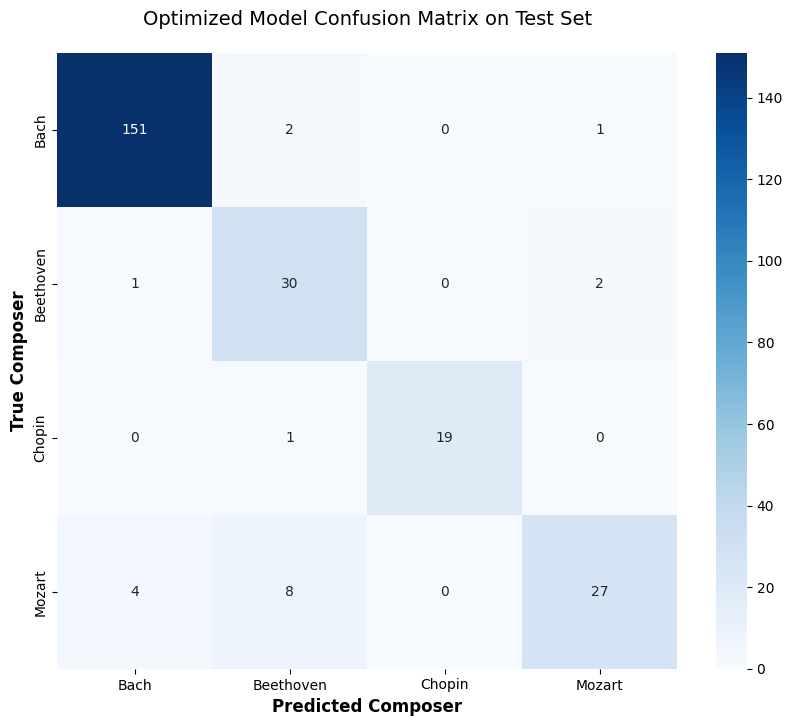

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_path = "/content/drive/MyDrive/data/processed/cnn/optimized_composer_cnn.pth"
print(f"Loading optimized model from: {model_path}")

loaded_model = ComposerCNN(num_classes=4).to(device)

loaded_model.load_state_dict(torch.load(model_path))

loaded_model.eval()

print("Evaluating loaded model on test set...")

test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = loaded_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = 100. * correct / total

print("=" * 40)
print(f"FINAL TEST RESULTS (Optimized Model) | Loss: {avg_test_loss:.4f} | Accuracy: {test_acc:.2f}%")
print("=" * 40)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=composer_classes,
    yticklabels=composer_classes
)
plt.xlabel('Predicted Composer', fontsize=12, fontweight='bold')
plt.ylabel('True Composer', fontsize=12, fontweight='bold')
plt.title('Optimized Model Confusion Matrix on Test Set', fontsize=14, pad=20)
plt.show()

In [72]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=composer_classes)

print("\nClassification Report (Optimized Model on Test Set):\n")
print(report)


Classification Report (Optimized Model on Test Set):

              precision    recall  f1-score   support

        Bach       0.97      0.98      0.97       154
   Beethoven       0.73      0.91      0.81        33
      Chopin       1.00      0.95      0.97        20
      Mozart       0.90      0.69      0.78        39

    accuracy                           0.92       246
   macro avg       0.90      0.88      0.89       246
weighted avg       0.93      0.92      0.92       246



In [53]:
import torch

# Define the path to save the entire model (architecture + weights)
save_path_full_model = "/content/drive/MyDrive/data/processed/cnn/optimized_composer_cnn_full_model.pth"

# Save the entire model
torch.save(final_model, save_path_full_model)

print(f"Entire optimized model (architecture + weights) saved to: {save_path_full_model}")

# To load it later:
# loaded_full_model = torch.load(save_path_full_model)
# loaded_full_model.eval()

Entire optimized model (architecture + weights) saved to: /content/drive/MyDrive/data/processed/cnn/optimized_composer_cnn_full_model.pth
